<a href="https://colab.research.google.com/github/Muhammad-Mukarram-Asad/Intro-to-python/blob/main/EDA_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install if needed: pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Style (like setting a CSS theme!)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
# Load dataset directly from URL — no download needed
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Shape = rows x columns (like array.length but 2D)
print(df.shape)           # (891, 12)

# Column names + data types (like typeof for each field)
print(df.info())

# First 5 rows — your "preview"
df.head()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
# Check missing values — like checking for undefined/null
print(df.isnull().sum())

# Output shows:
# Age     → 177 missing (fill with median)
# Cabin   → 687 missing (too many, drop it)
# Embarked → 2 missing (fill with mode)

df['Age'] = df['Age'].fillna(df['Age'].median())


# df['Embarked'].fillna({'Embarked' : df['Embarked'].mode()[0]}, inplace=True)

# newer way below for refilling the value:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# df.drop(columns=['Cabin'], inplace=True)

# Check for duplicate rows
print(f"Duplicates: {df.duplicated().sum()}")  # Should be 0

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Duplicates: 0


In [18]:
# Like getting a summary object of your data
df.describe()

# For categorical columns
print(df['Sex'].value_counts())
print(df['Pclass'].value_counts())

# Overall survival rate
print(f"Survival rate: {df['Survived'].mean()*100:.1f}%")
# → 38.4%

Sex
male      577
female    314
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Survival rate: 38.4%


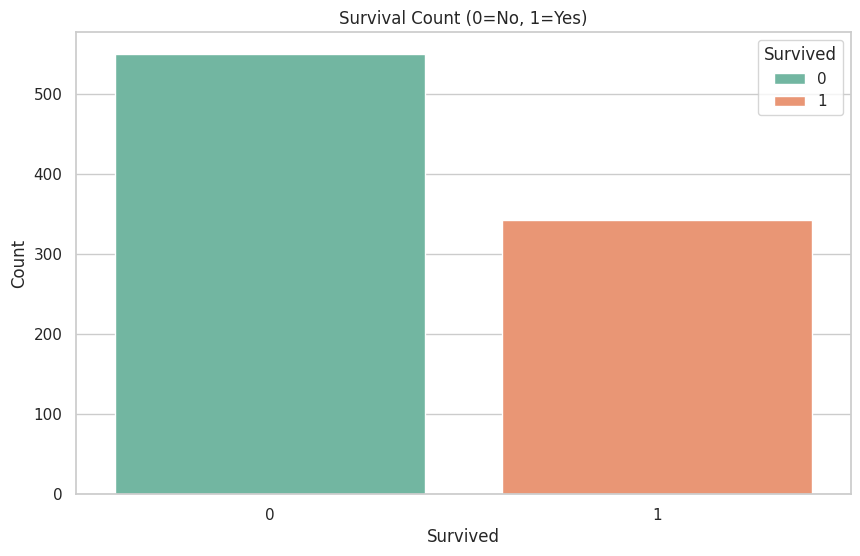

/tmp/ipykernel_2907/931017297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Set1')


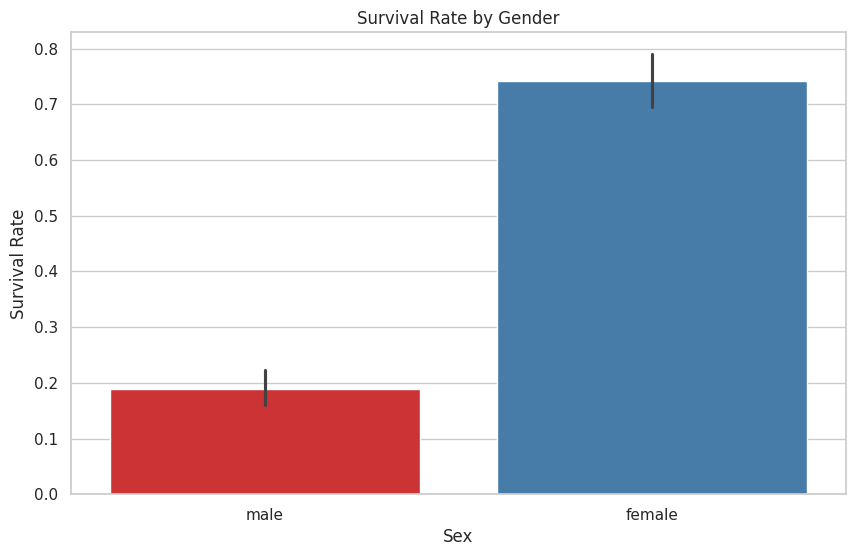

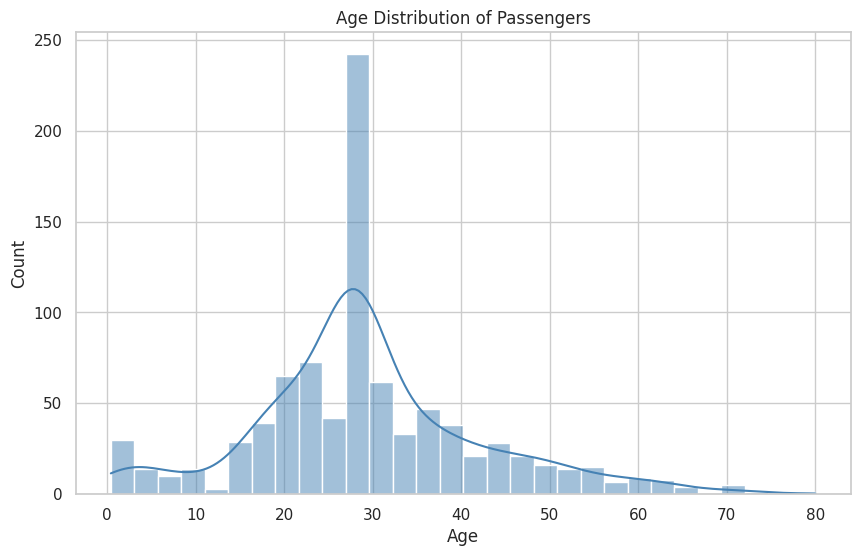

/tmp/ipykernel_2907/931017297.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df, palette='pastel')


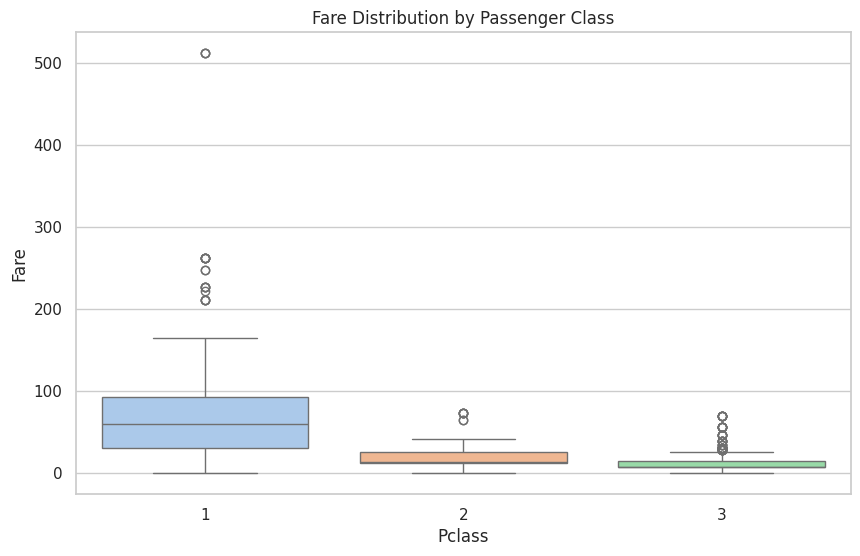

In [21]:
# --- Chart 1: How many survived? ---
sns.countplot(x='Survived', data=df, palette='Set2', hue='Survived')
plt.ylabel('Count')
plt.xlabel('Survived')
plt.title('Survival Count (0=No, 1=Yes)')
plt.show()

# --- Chart 2: Survival by gender ---
sns.barplot(x='Sex', y='Survived', data=df, palette='Set1')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

# --- Chart 3: Age distribution ---
sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Passengers')
plt.show()

# --- Chart 4: Fare vs Class (boxplot — shows spread & outliers) ---
sns.boxplot(x='Pclass', y='Fare', data=df, palette='pastel')
plt.title('Fare Distribution by Passenger Class')
plt.show()

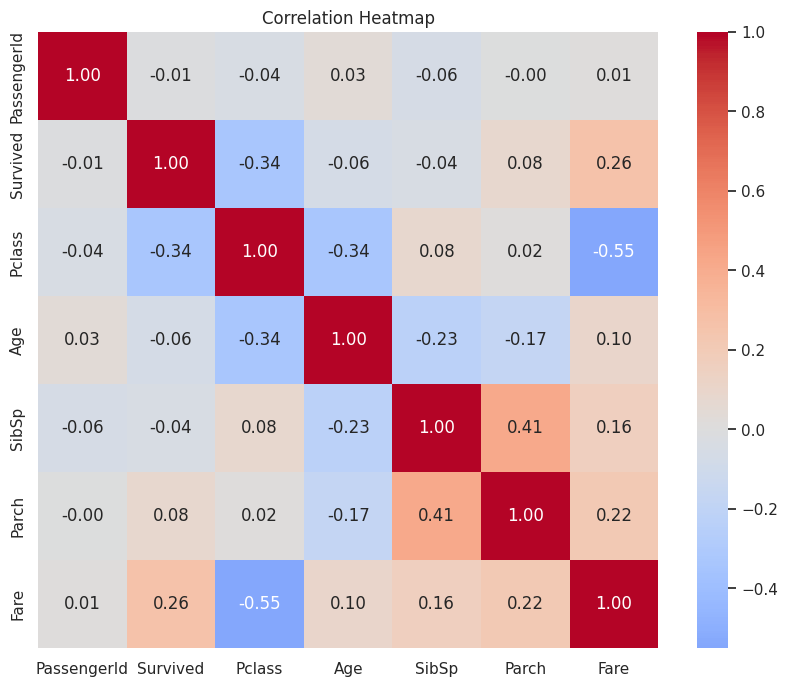

In [22]:
# Like finding which state variables affect each other
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,       # Show numbers on cells
    fmt='.2f',        # 2 decimal places
    cmap='coolwarm',  # Red=positive, Blue=negative
    center=0
)
plt.title('Correlation Heatmap')
plt.show()

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64 %
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


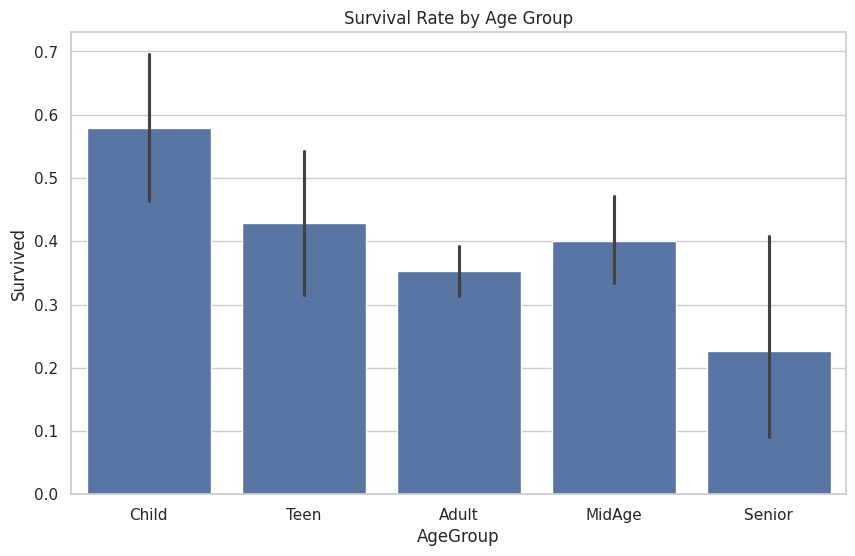

In [28]:
# Q: Did class affect survival?
print(f"{df.groupby('Pclass')['Survived'].mean()*100} %")
# 1st class: 63%  | 2nd: 47%  | 3rd: 24%  ← huge gap!

# Q: Women vs Men survival
print(df.groupby('Sex')['Survived'].mean())
# female: 74%  | male: 19%  ← "women and children first" was real

# Q: Age groups — did children survive more?
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                         labels=['Child','Teen','Adult','MidAge','Senior'])
sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.title('Survival Rate by Age Group')
plt.show()